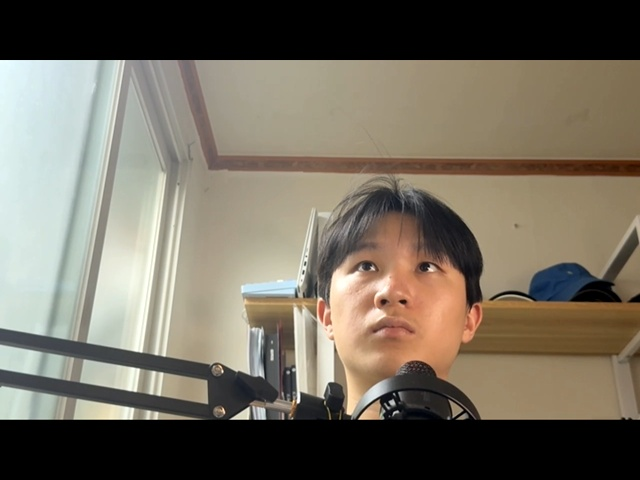

웹캠 실행 중... (중지하려면 셀 실행 중단(■) 버튼을 누르세요)
실행이 중단되었습니다.


In [ ]:
import cv2
import time
from hand_tracker import HandDetector
from utils import load_overlay_img, overlay_transparent

# 1. 파일 경로 지정
img_a_path = 'cat img1.webp'  
img_b_path = 'cat img2.jpg'   
img_c_path = 'cat img3.jpg'   

IMG_WIDTH = 150
IMG_HEIGHT = 150

img_a = load_overlay_img(img_a_path, size=(IMG_WIDTH, IMG_HEIGHT))
img_b = load_overlay_img(img_b_path, size=(IMG_WIDTH, IMG_HEIGHT))
img_c = load_overlay_img(img_c_path, size=(IMG_WIDTH, IMG_HEIGHT))

# 2. 인식 모델 및 카메라 초기화
detector = HandDetector()
cap = cv2.VideoCapture(0)

# 걷기 이벤트 0.5초 유지를 위한 시간 기록 딕셔너리
walk_display_times = {'Left': 0, 'Right': 0}

print("시작하려면 카메라 창을 클릭하고 'q'를 누르세요.")

# --- 메인 실행 루프 ---
while cap.isOpened():
    success, frame = cap.read()
    if not success: 
        break
    
    frame = cv2.flip(frame, 1) # 좌우 반전
    results = detector.find_hands(frame)
    hands_info = detector.get_hand_info(frame, results)
    
    current_time = time.time()
    
    for hand in hands_info:
        # 손가락 뼈대 및 관절 그리기
        detector.mp_draw.draw_landmarks(frame, hand["landmarks"], detector.mp_hands.HAND_CONNECTIONS)
        
        cx, cy = hand["center"]
        out_x = cx - (IMG_WIDTH // 2)
        out_y = cy - IMG_HEIGHT - 20
        label = hand["label"]
        
        # 걷기 이벤트가 발생하면 해당 손의 타이머를 현재 시간 기준 + 0.5초로 갱신
        if hand["is_walking"]:
            walk_display_times[label] = current_time + 0.5
            
        # 현재 시간이 타이머에 기록된 시간보다 작으면(0.5초 이내이면) 걷기 이미지 출력
        if current_time < walk_display_times[label]:
            frame = overlay_transparent(frame, img_c, out_x, out_y)
            
        # 걷기 상태가 아닐 때만 주먹 확인
        elif hand["is_fist"]:
            if label == "Left":
                frame = overlay_transparent(frame, img_a, out_x, out_y)
            elif label == "Right":
                frame = overlay_transparent(frame, img_b, out_x, out_y)

    # OpenCV 창으로 화면 출력
    cv2.imshow("Hand Control System", frame)
    
    # 'q' 키를 누르면 루프 종료
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()